# EDA — Traffic Crashes Resulting in Fatality

Notebook exploratorio para el dataset `Traffic_Crashes_Resulting_in_Fatality_20260527.csv`.

In [11]:
# Librerías principales
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=UserWarning)

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True

## 1. Carga del dataset

In [12]:
DATA_FILE = "accidentes-fatality-histo.csv"

data_path = Path(DATA_FILE)
if not data_path.exists():
    data_path = Path("../") / DATA_FILE

assert data_path.exists(), f"No se encontró el archivo: {data_path}"

df_raw = pd.read_csv(data_path, low_memory=False)
df = df_raw.copy()

print(f"Archivo: {data_path}")
print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]:,}")
display(df.head())

Archivo: ..\accidentes-fatality-histo.csv
Filas: 359
Columnas: 28


,unique_id,case_id_fkey,latitude,longitude,collision_year,death_date,death_time,death_datetime,collision_date,collision_time,collision_datetime,location,age,sex,deceased,collision_type,street_type,on_vz_hin_2017,in_coc_2018,publish,on_vz_hin_2022,in_epa_2021,point,analysis_neighborhood,supervisor_district,police_district,data_as_of,data_loaded_at
0,1,140236301,37.710,-122.404,2014,2014/03/20,11:21:00,2014/03/20 11:21:00 AM,2014/03/20,NaN,2014/03/20 12:00:00 AM,Bayshore Blvd near Visitation Ave,82.000,Female,Pedestrian,Pedestrian vs Motor Vehicle,City Street,False,False,True,True,False,POINT (-122.404226037 37.710409217),Bayview Hunters Point,10.000,INGLESIDE,2024/09/18 12:00:00 AM,2026/05/01 12:30:54 PM
1,2,140755533,37.725,-122.394,2014,2014/09/08,16:38:00,2014/09/08 04:38:00 PM,2014/09/08,05:10:00,2014/09/08 05:10:00 AM,3rd St at Carrol Ave,71.000,Male,Pedestrian,Pedestrian vs LRV,City Street,True,True,True,True,True,POINT (-122.394243493 37.72547565),Bayview Hunters Point,10.000,BAYVIEW,2024/09/18 12:00:00 AM,2026/05/01 12:30:54 PM
2,4,140365546,37.748,-122.414,2014,2014/05/03,17:20:00,2014/05/03 05:20:00 PM,2014/05/03,02:24:00,2014/05/03 02:24:00 AM,Folsom St and Caesar Chavez,26.000,Male,Driver,Motor Vehicle Collision,City Street,True,False,True,True,False,POINT (-122.413668844 37.748255329),Mission,9.000,MISSION,2024/09/18 12:00:00 AM,2026/05/01 12:30:54 PM
3,16,150562049,37.777,-122.420,2015,2015/06/30,06:00:00,2015/06/30 06:00:00 AM,2015/06/28,03:52:00,2015/06/28 03:52:00 AM,Van Ness Ave and Hayes St,52.000,Male,Motorcyclist,Motorcycle vs Motor Vehicle,City Street,True,False,True,True,True,POINT (-122.419693566 37.777299856),Tenderloin,5.000,NORTHERN,2024/09/18 12:00:00 AM,2026/05/01 12:30:54 PM
4,17,140104811,37.778,-122.420,2014,2014/02/06,10:20:00,2014/02/06 10:20:00 AM,2014/02/05,02:26:00,2014/02/05 02:26:00 AM,Van Ness Ave and Grove St,53.000,Male,Pedestrian,Pedestrian vs Motor Vehicle,City Street,True,False,True,True,True,POINT (-122.419883231 37.778251017),Hayes Valley,5.000,NORTHERN,2024/09/18 12:00:00 AM,2026/05/01 12:30:54 PM


## 2. Funciones auxiliares

In [13]:
def missingness_table(data: pd.DataFrame) -> pd.DataFrame:
    """Tabla de nulos ordenada por porcentaje descendente."""
    miss = data.isna().sum()
    out = (
        pd.DataFrame({
            "missing_count": miss,
            "missing_pct": miss / len(data) * 100,
            "dtype": data.dtypes.astype(str),
            "n_unique": data.nunique(dropna=True)
        })
        .sort_values(["missing_pct", "missing_count"], ascending=False)
    )
    return out


def cardinality_table(data: pd.DataFrame) -> pd.DataFrame:
    """Cardinalidad de variables categóricas / object."""
    obj_cols = data.select_dtypes(include=["object", "category", "bool"]).columns
    out = []
    for col in obj_cols:
        vc = data[col].value_counts(dropna=False)
        out.append({
            "column": col,
            "dtype": str(data[col].dtype),
            "n_unique": data[col].nunique(dropna=True),
            "top_value": vc.index[0] if len(vc) else np.nan,
            "top_count": vc.iloc[0] if len(vc) else np.nan,
            "top_pct": vc.iloc[0] / len(data) * 100 if len(vc) else np.nan
        })
    return pd.DataFrame(out).sort_values("n_unique", ascending=False)


def numeric_summary(data: pd.DataFrame) -> pd.DataFrame:
    """Resumen estadístico ampliado para columnas numéricas."""
    num = data.select_dtypes(include=[np.number])
    if num.empty:
        return pd.DataFrame()
    return num.describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).T


def top_categories(data: pd.DataFrame, columns, n=10) -> dict:
    """Devuelve las categorías más frecuentes para una lista de columnas."""
    result = {}
    for col in columns:
        if col in data.columns:
            result[col] = data[col].value_counts(dropna=False).head(n).to_frame("count")
            result[col]["pct"] = result[col]["count"] / len(data) * 100
    return result


def plot_counts(series: pd.Series, title: str, top_n: int = 15, xlabel: str = "Recuento"):
    """Bar chart horizontal de frecuencias."""
    counts = series.value_counts(dropna=False).head(top_n).sort_values()
    ax = counts.plot(kind="barh", figsize=(10, max(4, 0.35 * len(counts))))
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("")
    plt.tight_layout()
    plt.show()


def plot_time_counts(series: pd.Series, title: str, xlabel: str = ""):
    counts = series.value_counts().sort_index()
    ax = counts.plot(kind="line", marker="o")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Recuento")
    plt.tight_layout()
    plt.show()

## 3. Estructura, tipos de datos y duplicados

In [14]:
display(pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "non_null": df.notna().sum().values,
    "null_count": df.isna().sum().values,
    "n_unique": df.nunique(dropna=True).values
}))

print("Filas duplicadas completas:", df.duplicated().sum())
if "unique_id" in df.columns:
    print("unique_id duplicados:", df["unique_id"].duplicated().sum())
if "case_id_fkey" in df.columns:
    print("case_id_fkey duplicados:", df["case_id_fkey"].duplicated().sum())

,column,dtype,non_null,null_count,n_unique
0,unique_id,int64,359,0,359
1,case_id_fkey,str,352,7,343
2,latitude,float64,359,0,338
3,longitude,float64,359,0,337
4,collision_year,int64,359,0,13
5,death_date,str,359,0,329
6,death_time,str,323,36,287
7,death_datetime,str,359,0,352
8,collision_date,str,359,0,331
9,collision_time,str,334,25,288


Filas duplicadas completas: 0
unique_id duplicados: 0
case_id_fkey duplicados: 15


## 4. Nulos y cardinalidad

In [15]:
miss = missingness_table(df)
display(miss)

card = cardinality_table(df)
display(card)

,missing_count,missing_pct,dtype,n_unique
death_time,36,10.028,str,287
collision_time,25,6.964,str,288
case_id_fkey,7,1.950,str,343
age,1,0.279,float64,81
analysis_neighborhood,1,0.279,str,36
supervisor_district,1,0.279,float64,11
data_as_of,1,0.279,str,21
unique_id,0,0.000,int64,359
latitude,0,0.000,float64,338
longitude,0,0.000,float64,337


C:\Users\Samuel\AppData\Local\Temp\ipykernel_1624\3936774470.py:18: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  obj_cols = data.select_dtypes(include=["object", "category", "bool"]).columns


,column,dtype,n_unique,top_value,top_count,top_pct
3,death_datetime,str,352,2016/02/06 09:32:00 PM,3,0.836
6,collision_datetime,str,348,2024/03/16 12:13:00 PM,4,1.114
7,location,str,345,Ulloa St and Lenox Way,4,1.114
0,case_id_fkey,str,343,NaN,7,1.950
17,point,str,338,POINT (-122.466351712 37.741161679),4,1.114
4,collision_date,str,331,2024/03/16,4,1.114
1,death_date,str,329,2016/02/06,4,1.114
5,collision_time,str,288,NaN,25,6.964
2,death_time,str,287,NaN,36,10.028
18,analysis_neighborhood,str,36,Mission,39,10.864


## 5. Limpieza ligera y variables derivadas

In [16]:
# Fechas principales
date_cols = [
    "death_date", "death_datetime", "collision_date", "collision_datetime",
    "data_as_of", "data_loaded_at"
]

for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

# Tiempos separados: se mantienen como texto y se extrae hora cuando es posible.
for col in ["death_time", "collision_time"]:
    if col in df.columns:
        parsed_time = pd.to_datetime(df[col], errors="coerce")
        df[f"{col}_hour"] = parsed_time.dt.hour

# Variables temporales de la colisión
if "collision_datetime" in df.columns:
    df["collision_year_parsed"] = df["collision_datetime"].dt.year
    df["collision_month"] = df["collision_datetime"].dt.month
    df["collision_month_name"] = df["collision_datetime"].dt.month_name()
    df["collision_dayofweek"] = df["collision_datetime"].dt.day_name()
    df["collision_hour"] = df["collision_datetime"].dt.hour

# Diferencia entre fecha de colisión y fecha de fallecimiento
if {"collision_datetime", "death_datetime"}.issubset(df.columns):
    df["days_collision_to_death"] = (
        df["death_datetime"].dt.normalize() - df["collision_datetime"].dt.normalize()
    ).dt.days

# Edad numérica
if "age" in df.columns:
    df["age"] = pd.to_numeric(df["age"], errors="coerce")

display(df.head())

,unique_id,case_id_fkey,latitude,longitude,collision_year,death_date,death_time,death_datetime,collision_date,collision_time,collision_datetime,location,age,sex,deceased,collision_type,street_type,on_vz_hin_2017,in_coc_2018,publish,on_vz_hin_2022,in_epa_2021,point,analysis_neighborhood,supervisor_district,police_district,data_as_of,data_loaded_at,death_time_hour,collision_time_hour,collision_year_parsed,collision_month,collision_month_name,collision_dayofweek,collision_hour,days_collision_to_death
0,1,140236301,37.710,-122.404,2014,2014-03-20,11:21:00,2014-03-20 11:21:00,2014-03-20,NaN,2014-03-20 00:00:00,Bayshore Blvd near Visitation Ave,82.000,Female,Pedestrian,Pedestrian vs Motor Vehicle,City Street,False,False,True,True,False,POINT (-122.404226037 37.710409217),Bayview Hunters Point,10.000,INGLESIDE,2024-09-18,2026-05-01 12:30:54,11.000,NaN,2014,3,March,Thursday,0,0
1,2,140755533,37.725,-122.394,2014,2014-09-08,16:38:00,2014-09-08 16:38:00,2014-09-08,05:10:00,2014-09-08 05:10:00,3rd St at Carrol Ave,71.000,Male,Pedestrian,Pedestrian vs LRV,City Street,True,True,True,True,True,POINT (-122.394243493 37.72547565),Bayview Hunters Point,10.000,BAYVIEW,2024-09-18,2026-05-01 12:30:54,16.000,5.000,2014,9,September,Monday,5,0
2,4,140365546,37.748,-122.414,2014,2014-05-03,17:20:00,2014-05-03 17:20:00,2014-05-03,02:24:00,2014-05-03 02:24:00,Folsom St and Caesar Chavez,26.000,Male,Driver,Motor Vehicle Collision,City Street,True,False,True,True,False,POINT (-122.413668844 37.748255329),Mission,9.000,MISSION,2024-09-18,2026-05-01 12:30:54,17.000,2.000,2014,5,May,Saturday,2,0
3,16,150562049,37.777,-122.420,2015,2015-06-30,06:00:00,2015-06-30 06:00:00,2015-06-28,03:52:00,2015-06-28 03:52:00,Van Ness Ave and Hayes St,52.000,Male,Motorcyclist,Motorcycle vs Motor Vehicle,City Street,True,False,True,True,True,POINT (-122.419693566 37.777299856),Tenderloin,5.000,NORTHERN,2024-09-18,2026-05-01 12:30:54,6.000,3.000,2015,6,June,Sunday,3,2
4,17,140104811,37.778,-122.420,2014,2014-02-06,10:20:00,2014-02-06 10:20:00,2014-02-05,02:26:00,2014-02-05 02:26:00,Van Ness Ave and Grove St,53.000,Male,Pedestrian,Pedestrian vs Motor Vehicle,City Street,True,False,True,True,True,POINT (-122.419883231 37.778251017),Hayes Valley,5.000,NORTHERN,2024-09-18,2026-05-01 12:30:54,10.000,2.000,2014,2,February,Wednesday,2,1


## 6. Resumen estadístico

In [17]:
display(numeric_summary(df))

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
unique_id,359.000,"13,473,358.844","106,866,088.646",1.000,5.160,21.900,117.500,282.000,"20,230,943.000","20,251,044.000","20,260,298.420","2,024,039,699.000"
latitude,359.000,37.762,0.028,37.709,37.709,37.713,37.739,37.769,37.784,37.800,37.808,37.823
longitude,359.000,-122.428,0.030,-122.513,-122.506,-122.493,-122.443,-122.420,-122.408,-122.392,-122.376,-122.370
collision_year,359.000,"2,019.827",3.589,"2,014.000","2,014.000","2,014.000","2,016.500","2,020.000","2,023.000","2,025.000","2,026.000","2,026.000"
age,358.000,52.500,20.924,0.000,3.140,23.000,34.000,53.000,68.000,85.150,90.860,95.000
supervisor_district,358.000,6.346,3.058,1.000,1.000,1.000,4.000,6.000,9.000,11.000,11.000,11.000
death_time_hour,323.000,12.433,7.166,0.000,0.000,1.000,6.000,13.000,19.000,23.000,23.000,23.000
collision_time_hour,334.000,12.165,7.115,0.000,0.000,1.000,6.000,13.000,18.000,23.000,23.000,23.000
collision_year_parsed,359.000,"2,019.827",3.589,"2,014.000","2,014.000","2,014.000","2,016.500","2,020.000","2,023.000","2,025.000","2,026.000","2,026.000"
collision_month,359.000,6.652,3.453,1.000,1.000,1.000,3.000,7.000,10.000,12.000,12.000,12.000


## 7. Distribuciones de víctimas y tipos de colisión


Top categorías — deceased


,count,pct
deceased,,
Pedestrian,211,58.774
Motorcyclist,48,13.370
Driver,42,11.699
Bicyclist,25,6.964
Passenger,18,5.014
Standup Powered Device Rider,10,2.786
Exterior Passenger,3,0.836
Moped,2,0.557



Top categorías — sex


,count,pct
sex,,
Male,253,70.474
Female,106,29.526



Top categorías — collision_type


...

,count,pct
analysis_neighborhood,,
Mission,39,10.864
Bayview Hunters Point,30,8.357
Tenderloin,28,7.799
South of Market,27,7.521
Financial District/South Beach,16,4.457
Sunset/Parkside,14,3.900
West of Twin Peaks,13,3.621
Marina,13,3.621
Hayes Valley,12,3.343



Top categorías — police_district


,count,pct
police_district,,
NORTHERN,51,14.206
SOUTHERN,48,13.370
BAYVIEW,46,12.813
TARAVAL,44,12.256
MISSION,43,11.978
INGLESIDE,42,11.699
CENTRAL,29,8.078
RICHMOND,27,7.521
PARK,15,4.178



Top categorías — supervisor_district


,count,pct
supervisor_district,,
6.000,51,14.206
9.000,50,13.928
5.000,43,11.978
10.000,39,10.864
3.000,37,10.306
11.000,32,8.914
7.000,25,6.964
2.000,25,6.964
1.000,23,6.407


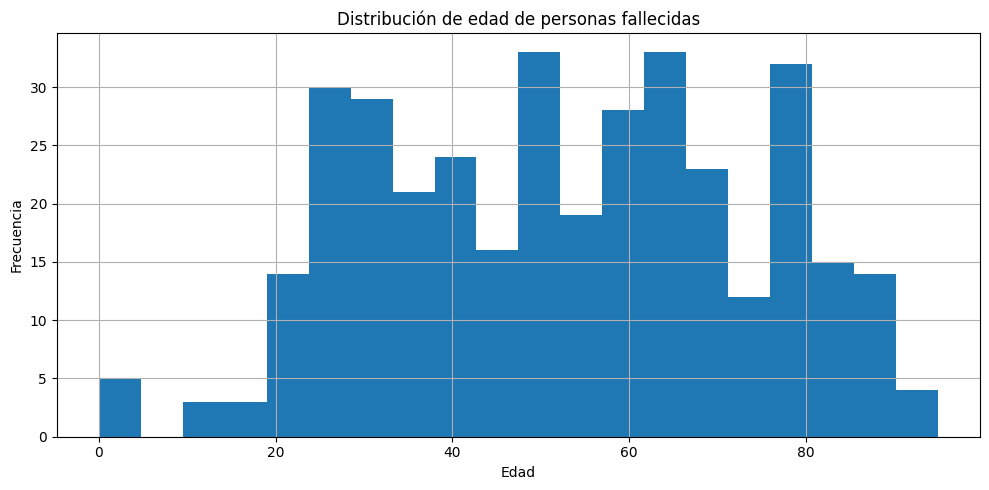

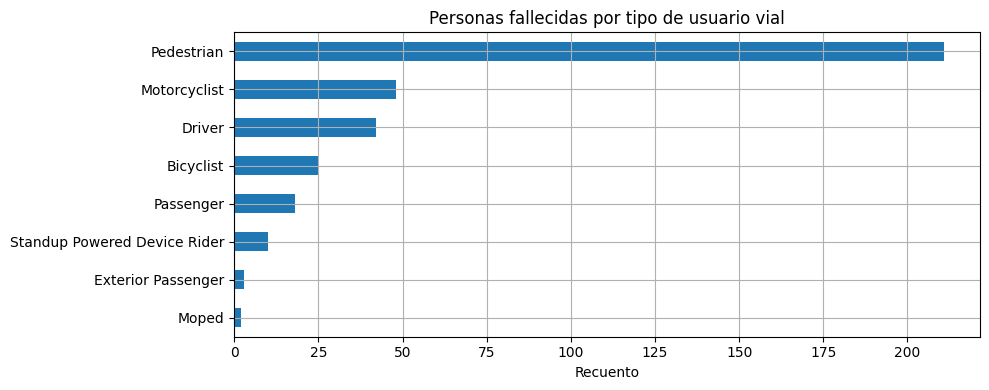

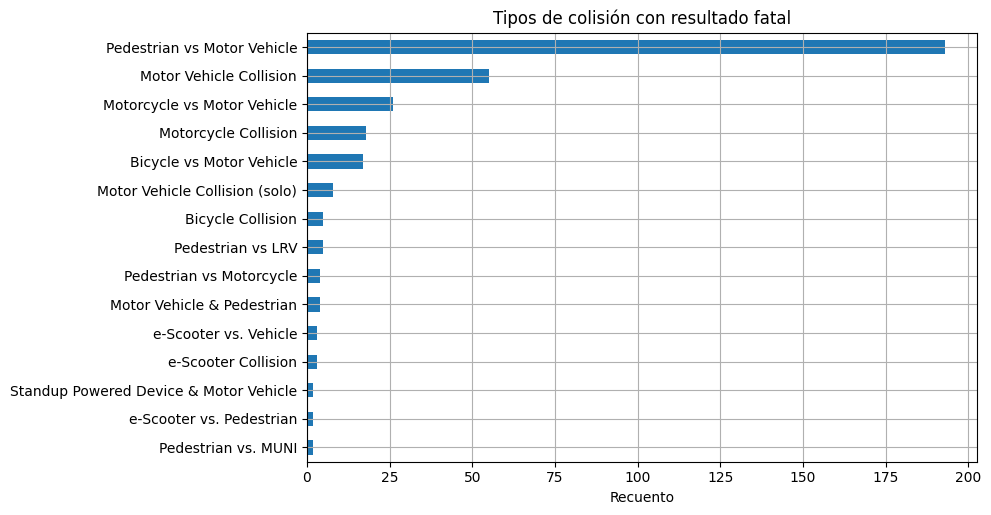

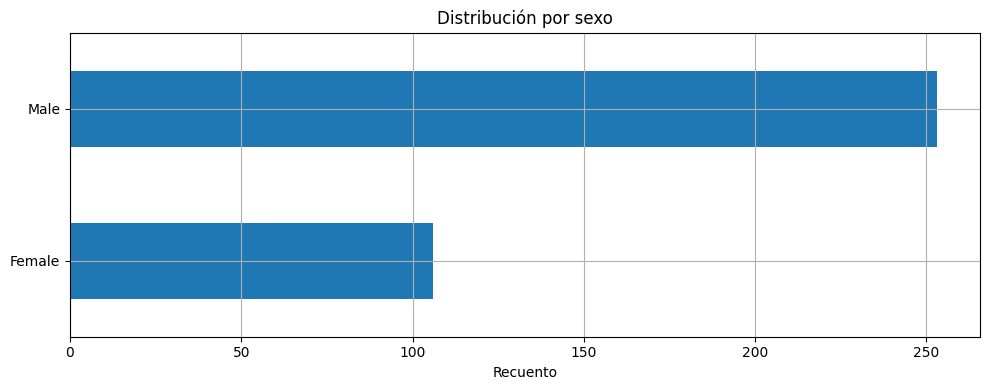

In [18]:
categorical_cols = [
    "deceased", "sex", "collision_type", "street_type",
    "analysis_neighborhood", "police_district", "supervisor_district"
]

tops = top_categories(df, categorical_cols, n=15)
for col, table in tops.items():
    print(f"\nTop categorías — {col}")
    display(table)

if "age" in df.columns:
    ax = df["age"].dropna().plot(kind="hist", bins=20)
    ax.set_title("Distribución de edad de personas fallecidas")
    ax.set_xlabel("Edad")
    ax.set_ylabel("Frecuencia")
    plt.tight_layout()
    plt.show()

if "deceased" in df.columns:
    plot_counts(df["deceased"], "Personas fallecidas por tipo de usuario vial", top_n=15)

if "collision_type" in df.columns:
    plot_counts(df["collision_type"], "Tipos de colisión con resultado fatal", top_n=15)

if "sex" in df.columns:
    plot_counts(df["sex"], "Distribución por sexo", top_n=10)

## 8. Patrones temporales

,fatalities
collision_year,
2014,30
2015,31
2016,29
2017,20
2018,23
2019,29
2020,30
2021,27
2022,39


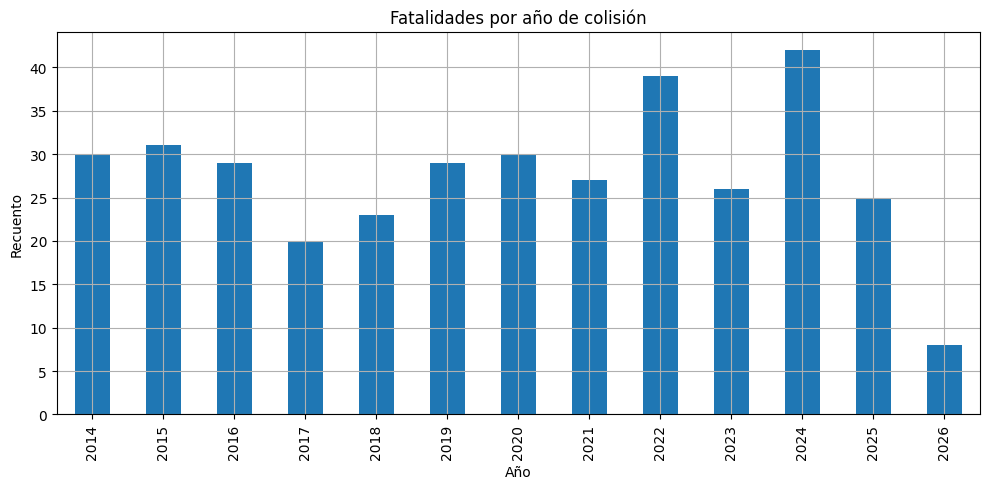

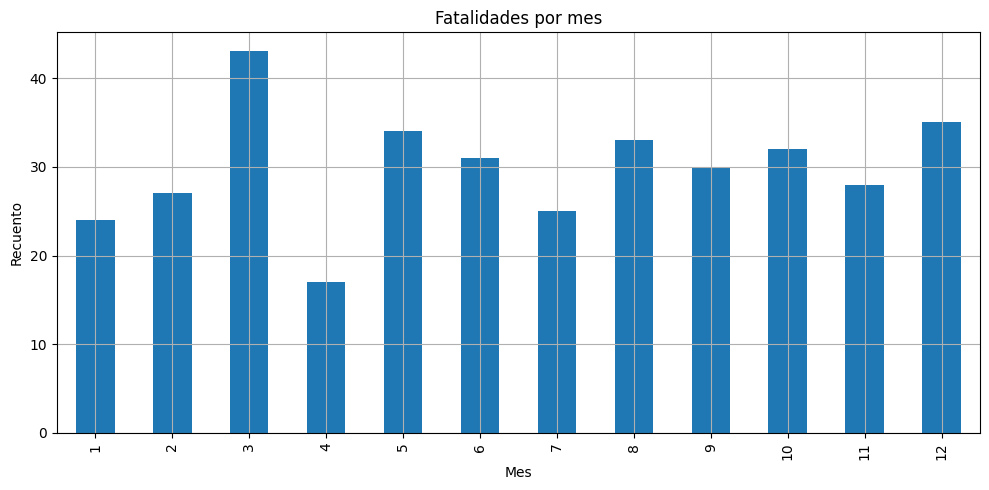

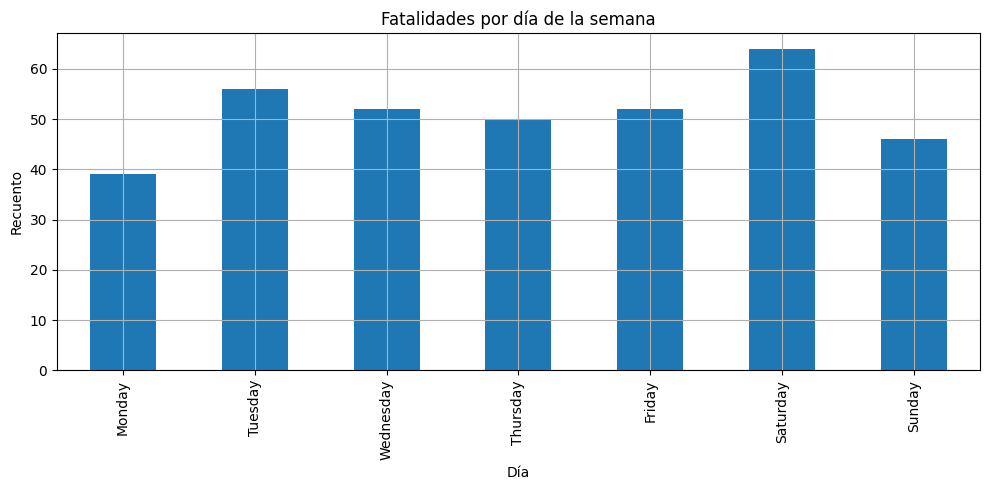

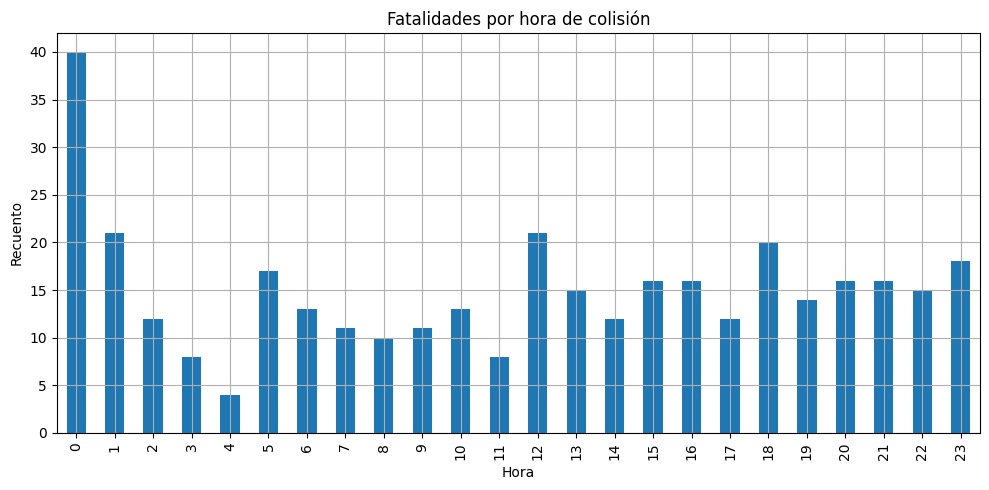

In [19]:
if "collision_year" in df.columns:
    year_counts = df["collision_year"].value_counts().sort_index()
    display(year_counts.to_frame("fatalities"))
    ax = year_counts.plot(kind="bar")
    ax.set_title("Fatalidades por año de colisión")
    ax.set_xlabel("Año")
    ax.set_ylabel("Recuento")
    plt.tight_layout()
    plt.show()

if "collision_month" in df.columns:
    month_counts = df["collision_month"].value_counts().sort_index()
    ax = month_counts.plot(kind="bar")
    ax.set_title("Fatalidades por mes")
    ax.set_xlabel("Mes")
    ax.set_ylabel("Recuento")
    plt.tight_layout()
    plt.show()

if "collision_dayofweek" in df.columns:
    order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
    dow_counts = df["collision_dayofweek"].value_counts().reindex(order)
    ax = dow_counts.plot(kind="bar")
    ax.set_title("Fatalidades por día de la semana")
    ax.set_xlabel("Día")
    ax.set_ylabel("Recuento")
    plt.tight_layout()
    plt.show()

if "collision_hour" in df.columns:
    hour_counts = df["collision_hour"].value_counts().sort_index()
    ax = hour_counts.plot(kind="bar")
    ax.set_title("Fatalidades por hora de colisión")
    ax.set_xlabel("Hora")
    ax.set_ylabel("Recuento")
    plt.tight_layout()
    plt.show()

## 9. Tiempo entre colisión y fallecimiento

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
days_collision_to_death,359.000,-1.242,42.329,-706.000,-7.460,0.000,0.000,0.000,1.000,12.000,20.420,28.000


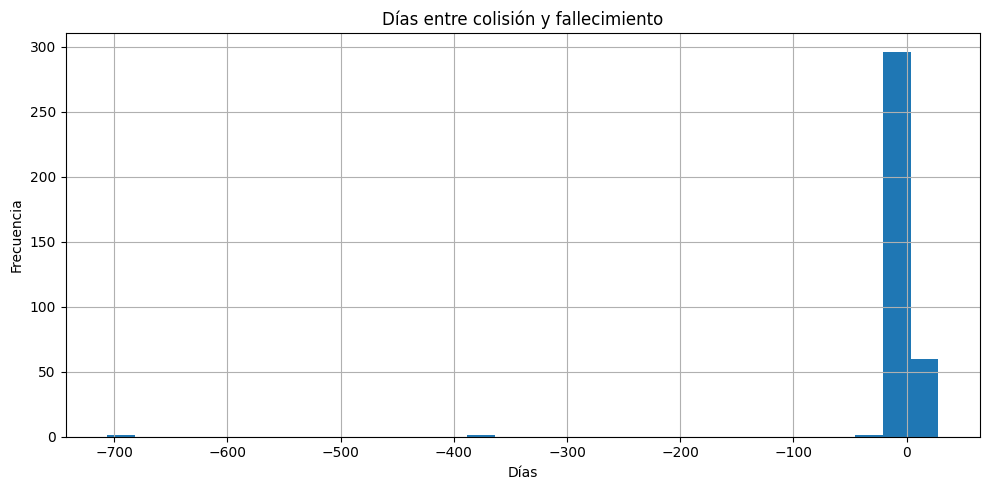

,unique_id,case_id_fkey,collision_datetime,death_datetime,days_collision_to_death,location
194,316,210312431,2021-05-21 11:14:00,2019-06-15 22:29:00,-706,California Street and Hyde Street
273,106,160344304,2016-04-27 00:00:00,2015-04-27 13:32:00,-366,The Embarcadero and Bryant Street
353,65,150890602,2015-11-11 15:20:00,2015-10-11 15:32:00,-31,IFO 532 Market Street
195,317,210330706,2021-05-28 21:22:00,2021-06-25 14:48:00,28,16th Street and Folsom Street
12,7,150507164,2015-06-11 14:56:00,2015-07-05 15:00:00,24,Persia Ave and Mission Street
115,23,141027204,2014-12-06 00:00:00,2014-12-29 00:20:00,23,Folsom St and 2nd St
288,25,150513246,2015-06-12 12:25:00,2015-07-03 21:08:00,21,Mission St and Oliver St
161,68,150762744,2015-08-31 07:26:00,2015-09-20 12:46:00,20,21 Gaven St
214,298,200788171,2020-12-30 00:00:00,2021-01-19 00:00:00,20,Gough Street and Market Street
183,164,180862035,2018-11-13 12:00:00,2018-12-02 04:05:00,19,3rd Street and Armstrong Avenue


In [20]:
if "days_collision_to_death" in df.columns:
    display(df["days_collision_to_death"].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).to_frame().T)

    ax = df["days_collision_to_death"].dropna().plot(kind="hist", bins=30)
    ax.set_title("Días entre colisión y fallecimiento")
    ax.set_xlabel("Días")
    ax.set_ylabel("Frecuencia")
    plt.tight_layout()
    plt.show()

    display(
        df.loc[df["days_collision_to_death"].abs().sort_values(ascending=False).index,
               ["unique_id", "case_id_fkey", "collision_datetime", "death_datetime", "days_collision_to_death", "location"]]
        .head(20)
    )

## 10. Análisis geográfico

,latitude,longitude,point,location,analysis_neighborhood,police_district,supervisor_district
0,37.710,-122.404,POINT (-122.404226037 37.710409217),Bayshore Blvd near Visitation Ave,Bayview Hunters Point,INGLESIDE,10.000
1,37.725,-122.394,POINT (-122.394243493 37.72547565),3rd St at Carrol Ave,Bayview Hunters Point,BAYVIEW,10.000
2,37.748,-122.414,POINT (-122.413668844 37.748255329),Folsom St and Caesar Chavez,Mission,MISSION,9.000
3,37.777,-122.420,POINT (-122.419693566 37.777299856),Van Ness Ave and Hayes St,Tenderloin,NORTHERN,5.000
4,37.778,-122.420,POINT (-122.419883231 37.778251017),Van Ness Ave and Grove St,Hayes Valley,NORTHERN,5.000


Coordenadas faltantes:


,missing
latitude,0
longitude,0


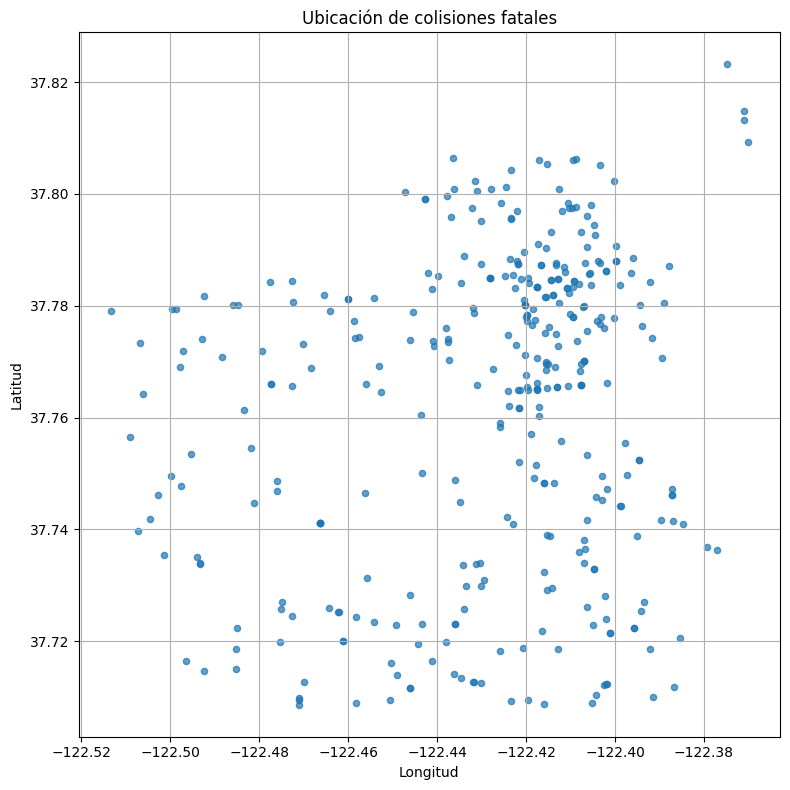

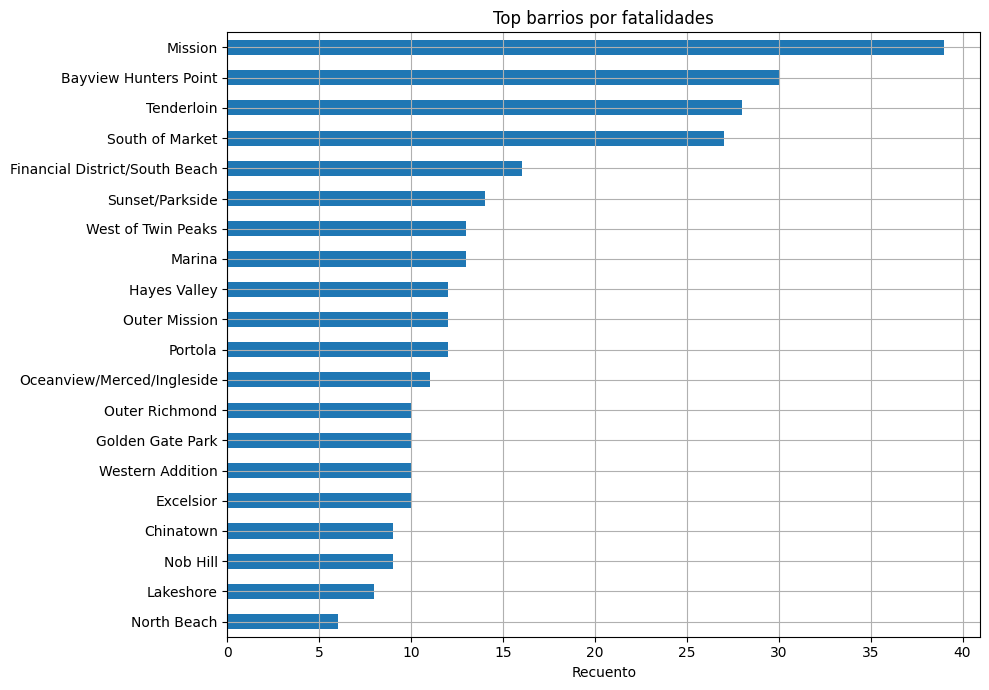

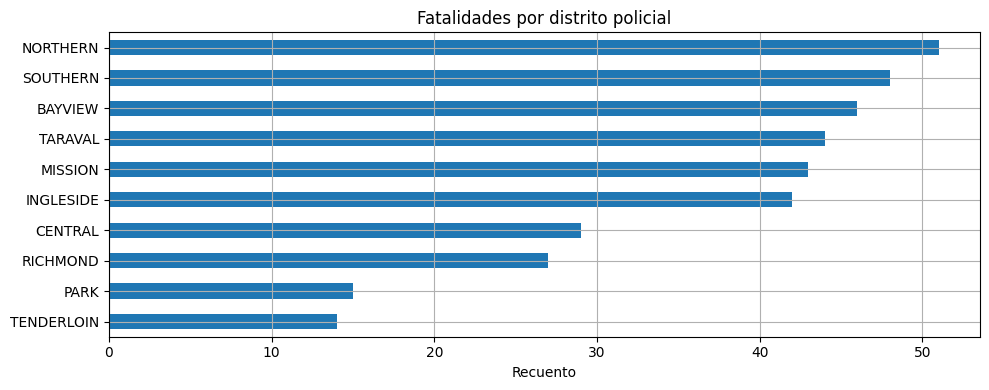

In [21]:
geo_cols = ["latitude", "longitude", "point", "location", "analysis_neighborhood", "police_district", "supervisor_district"]
display(df[[c for c in geo_cols if c in df.columns]].head())

if {"latitude", "longitude"}.issubset(df.columns):
    print("Coordenadas faltantes:")
    display(df[["latitude", "longitude"]].isna().sum().to_frame("missing"))

    geo = df.dropna(subset=["latitude", "longitude"])
    ax = geo.plot(kind="scatter", x="longitude", y="latitude", alpha=0.7, figsize=(8, 8))
    ax.set_title("Ubicación de colisiones fatales")
    ax.set_xlabel("Longitud")
    ax.set_ylabel("Latitud")
    plt.tight_layout()
    plt.show()

if "analysis_neighborhood" in df.columns:
    plot_counts(df["analysis_neighborhood"], "Top barrios por fatalidades", top_n=20)

if "police_district" in df.columns:
    plot_counts(df["police_district"], "Fatalidades por distrito policial", top_n=20)

## 11. Vision Zero / indicadores espaciales

In [22]:
flag_cols = [c for c in ["on_vz_hin_2017", "in_coc_2018", "on_vz_hin_2022", "in_epa_2021", "publish"] if c in df.columns]

if flag_cols:
    flag_summary = pd.DataFrame({
        col: df[col].value_counts(dropna=False)
        for col in flag_cols
    }).fillna(0).astype(int)
    display(flag_summary)

    flag_rates = pd.DataFrame({
        "true_count": [df[col].eq(True).sum() for col in flag_cols],
        "true_pct": [df[col].eq(True).mean() * 100 for col in flag_cols]
    }, index=flag_cols)
    display(flag_rates.sort_values("true_pct", ascending=False))

,on_vz_hin_2017,in_coc_2018,on_vz_hin_2022,in_epa_2021,publish
False,139,179,132,214,0
True,220,180,227,145,359


,true_count,true_pct
publish,359,100.000
on_vz_hin_2022,227,63.231
on_vz_hin_2017,220,61.281
in_coc_2018,180,50.139
in_epa_2021,145,40.390


## 12. Checks de calidad de datos

In [23]:
checks = {}

if "age" in df.columns:
    checks["age_missing"] = df["age"].isna().sum()
    checks["age_lt_0"] = (df["age"] < 0).sum()
    checks["age_gt_110"] = (df["age"] > 110).sum()

if {"latitude", "longitude"}.issubset(df.columns):
    checks["lat_missing"] = df["latitude"].isna().sum()
    checks["lon_missing"] = df["longitude"].isna().sum()
    # Bounding box aproximado de San Francisco.
    checks["coords_outside_sf_bbox"] = (
        ~df["latitude"].between(37.60, 37.85) |
        ~df["longitude"].between(-122.55, -122.30)
    ).sum()

if {"collision_datetime", "death_datetime"}.issubset(df.columns):
    checks["death_before_collision"] = (df["death_datetime"] < df["collision_datetime"]).sum()

if "unique_id" in df.columns:
    checks["unique_id_duplicates"] = df["unique_id"].duplicated().sum()

quality_checks = pd.Series(checks, name="count").to_frame()
display(quality_checks)

# Filas candidatas a revisión.
review_cols = [
    "unique_id", "case_id_fkey", "collision_datetime", "death_datetime",
    "days_collision_to_death", "age", "latitude", "longitude", "location",
    "collision_type", "deceased"
]
review_cols = [c for c in review_cols if c in df.columns]

conditions = pd.Series(False, index=df.index)
if "age" in df.columns:
    conditions |= df["age"].lt(0).fillna(False) | df["age"].gt(110).fillna(False)
if {"latitude", "longitude"}.issubset(df.columns):
    conditions |= (
        ~df["latitude"].between(37.60, 37.85) |
        ~df["longitude"].between(-122.55, -122.30)
    ).fillna(False)
if {"collision_datetime", "death_datetime"}.issubset(df.columns):
    conditions |= (df["death_datetime"] < df["collision_datetime"]).fillna(False)

display(df.loc[conditions, review_cols].head(50))

,count
age_missing,1
age_lt_0,0
age_gt_110,0
lat_missing,0
lon_missing,0
coords_outside_sf_bbox,0
death_before_collision,37
unique_id_duplicates,0


,unique_id,case_id_fkey,collision_datetime,death_datetime,days_collision_to_death,age,latitude,longitude,location,collision_type,deceased
20,20240346,240152047,2024-03-08 15:20:00,2024-03-08 03:41:00,0,48.000,37.769,-122.468,Martin Luther King Dr and Music Concourse Dr,Motorcycle Collision,Motorcyclist
39,20250670,250265191,2025-05-12 06:51:00,2025-05-12 06:38:00,0,47.000,37.746,-122.404,Bayshore Blvd Curve near 151 and 185 Bayshore ...,Pedestrian vs Motor Vehicle,Pedestrian
53,104,160413852,2016-05-22 00:00:00,2016-05-20 23:07:00,-2,52.000,37.765,-122.413,Westbound on 16th Street and Harrison Street,Motorcycle Collision,Motorcyclist
54,220,190455222,2019-06-24 03:03:00,2019-06-24 00:00:00,0,56.000,37.784,-122.473,California Street and Funston Avenue,Motor Vehicle Collision,Driver
61,20251550,250704365,2025-12-17 18:05:00,2025-12-17 00:00:00,0,80.000,37.712,-122.446,Mission St and Naglee Ave,Pedestrian vs Motor Vehicle,Pedestrian
64,20260390,260171873,2026-03-27 07:43:00,2026-03-27 00:00:00,0,49.000,37.796,-122.406,670 Jackson St at Grant St,Pedestrian vs Motor Vehicle,Pedestrian
84,40,140931200,2014-11-03 13:49:00,2014-11-03 13:15:00,0,64.000,37.766,-122.420,1984 Mission St,Pedestrian vs Motor Vehicle,Pedestrian
110,325,210606701,2021-09-19 02:23:00,2021-09-19 01:58:00,0,39.000,37.736,-122.408,Alemany Blvd at San Bruno Ave,Motor Vehicle Collision,Driver
151,54,140939527,2014-11-06 06:10:00,2014-11-06 00:00:00,0,51.000,37.801,-122.425,Lombard St and Van Ness Ave,Pedestrian vs Motor Vehicle,Pedestrian
166,231,190824207,2019-10-31 15:26:00,2019-10-31 00:00:00,0,69.000,37.760,-122.417,South Van Ness Ave at 19th St,Pedestrian vs Motor Vehicle,Pedestrian


## 13. Exportación de tablas del EDA

In [24]:
output_dir = Path("eda_outputs_fatality")
output_dir.mkdir(exist_ok=True)

missingness_table(df).to_csv(output_dir / "missingness_fatality.csv")
cardinality_table(df).to_csv(output_dir / "cardinality_fatality.csv", index=False)
numeric_summary(df).to_csv(output_dir / "numeric_summary_fatality.csv")
quality_checks.to_csv(output_dir / "quality_checks_fatality.csv")

print(f"Tablas exportadas en: {output_dir.resolve()}")

Tablas exportadas en: C:\Users\Samuel\Desktop\SF_STREETS\Repo_raw\proyecto-carreteras-sf-fantastic-four\EDA-Accidentes\eda_outputs_fatality


C:\Users\Samuel\AppData\Local\Temp\ipykernel_1624\3936774470.py:18: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  obj_cols = data.select_dtypes(include=["object", "category", "bool"]).columns


## 14. Conclusiones iniciales

In [26]:
summary = {
    "n_rows": len(df),
    "n_columns": df.shape[1],
    "date_min": df["collision_datetime"].min() if "collision_datetime" in df.columns else None,
    "date_max": df["collision_datetime"].max() if "collision_datetime" in df.columns else None,
    "top_collision_type": df["collision_type"].value_counts().idxmax() if "collision_type" in df.columns else None,
    "top_collision_type_count": df["collision_type"].value_counts().max() if "collision_type" in df.columns else None,
    "top_deceased": df["deceased"].value_counts().idxmax() if "deceased" in df.columns else None,
    "top_deceased_count": df["deceased"].value_counts().max() if "deceased" in df.columns else None,
    "top_neighborhood": df["analysis_neighborhood"].value_counts().idxmax() if "analysis_neighborhood" in df.columns else None,
    "top_neighborhood_count": df["analysis_neighborhood"].value_counts().max() if "analysis_neighborhood" in df.columns else None,
}

for k, v in summary.items():
    print(f"{k}: {v}")

n_rows: 359
n_columns: 36
date_min: 2014-01-04 18:20:00
date_max: 2026-03-27 07:43:00
top_collision_type: Pedestrian vs Motor Vehicle
top_collision_type_count: 193
top_deceased: Pedestrian
top_deceased_count: 211
top_neighborhood: Mission
top_neighborhood_count: 39
